<a href="https://colab.research.google.com/github/pinkadace-code/fita-ml-course/blob/main/week2/week2_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


url = 'https://raw.githubusercontent.com/pinkadace-code/fita-ml-course/main/week1/shoppers_clean.csv'
df = pd.read_csv(url)
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")

Datu kopa: 12330 rindas, 28 kolonnas


PageValues statistika:
count    1.233000e+04
mean     1.383052e-16
std      1.000041e+00
min     -3.171778e-01
25%     -3.171778e-01
50%     -3.171778e-01
75%     -3.171778e-01
max      1.916634e+01
Name: PageValues, dtype: float64


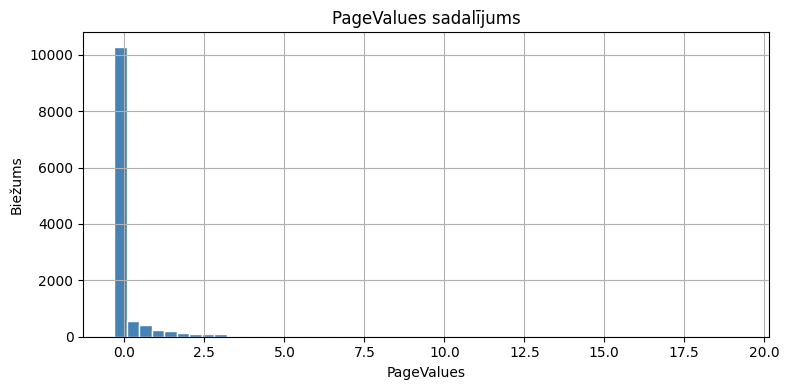

In [2]:
print("PageValues statistika:")
print(df['PageValues'].describe())

plt.figure(figsize=(8, 4))
df['PageValues'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('PageValues sadalījums')
plt.xlabel('PageValues')
plt.ylabel('Biežums')
plt.tight_layout()
plt.show()


In [3]:
# Target
y = df['PageValues']

# Features — visas kolonnas, izņemot PageValues un Revenue
X = df.drop(['PageValues', 'Revenue'], axis=1)

print(f"Features skaits: {X.shape[1]}")
print(f"Target: PageValues")


Features skaits: 26
Target: PageValues


Kolonna "Revenue" tika izņemta, lai šī informācija modelim nebūtu pieejama.

"Data leakage" notiek, kad modelis trenēšanas laikā saņem informāciju, kas reālā situācijā tam nebūtu pieejama. Ja kolonna tiktu atstāta, modelis jau "zinātu atbildi"
un uzrādītu izcilus rezultātus trenēšanā.

Tas ir bīstami, jo pretējā gadījumā modelis šķistu precīzs testos, bet īstajā pārbaudē nedarbotos, un šādu kļūdu būtu grūti pēc tam pamanīt.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Treniņa kopa: {X_train.shape[0]} rindas")
print(f"Testa kopa: {X_test.shape[0]} rindas")


Treniņa kopa: 9864 rindas
Testa kopa: 2466 rindas


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Izveido un uztrenē modeli
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prognozes
y_pred = lr_model.predict(X_test)

# Metrikas
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Lineāra regresija: rezultāti ===")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")


=== Lineāra regresija: rezultāti ===
MSE:  0.9892
RMSE: 0.9946
MAE:  0.5009
R²:   0.0456


MAE (Mean Absolute Error) — Vidējā absolūtā kļūda
MAE parāda, par cik standartnovirzes vienībām vidēji modelis kļūdās savās prognozēs.
MAE 0.50 nozīmē, ka kļūda ir liela — tā ir puse no visas datu izkliedes.

RMSE (Root Mean Squared Error) kāpina kļūdas kvadrātā, tā lielākām kļūdām pešķirot lielāku svaru. RMSE 0.99 ir gandrīz vienāds ar standartnovirzi, kas norāda, ka modelis gandrīz neko nav iemācījies.

R² (R-squared) parāda, cik lielu daļu datu dažādības modelis spēj izskaidrot.
R² 0.0456 nozīmē, ka modelis spēj izskaidrot tikai 4.56% no PageValues vērtībām, tas gandrīz nesaprot, kādēļ vērtības tik ļoti atšķiras.

Spriežot pēc rezultātiem, modelis ir slikts.
Iemesls, visticamāk, ir datu nelīdzsvarotība — lielākajai daļai
apmeklētāju PageValues = 0 (nenopirka), un modelis nespēj labi strādāt ar šādu sadalījumu.

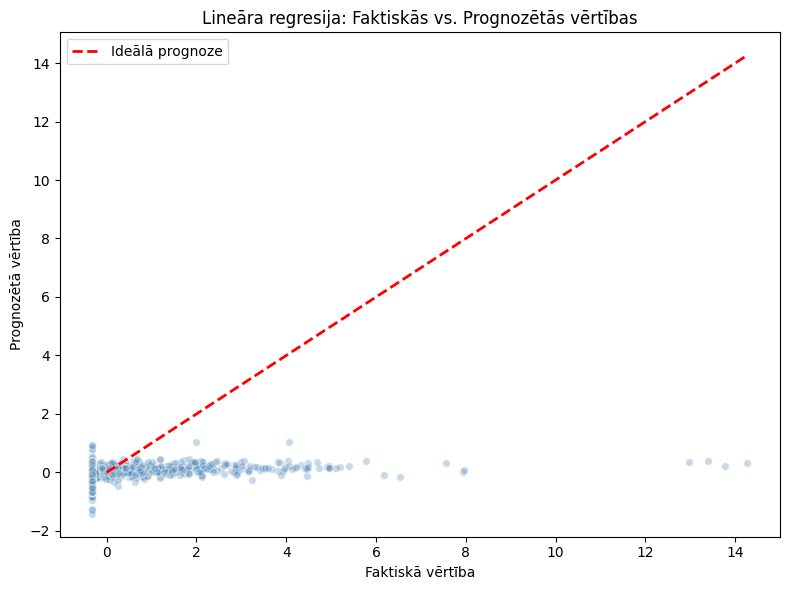

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='white', s=30)

# Ideālā līnija (ja prognoze = realitāte)
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Ideālā prognoze')

plt.xlabel('Faktiskā vērtība')
plt.ylabel('Prognozētā vērtība')
plt.title('Lineāra regresija: Faktiskās vs. Prognozētās vērtības')
plt.legend()
plt.tight_layout()
plt.show()


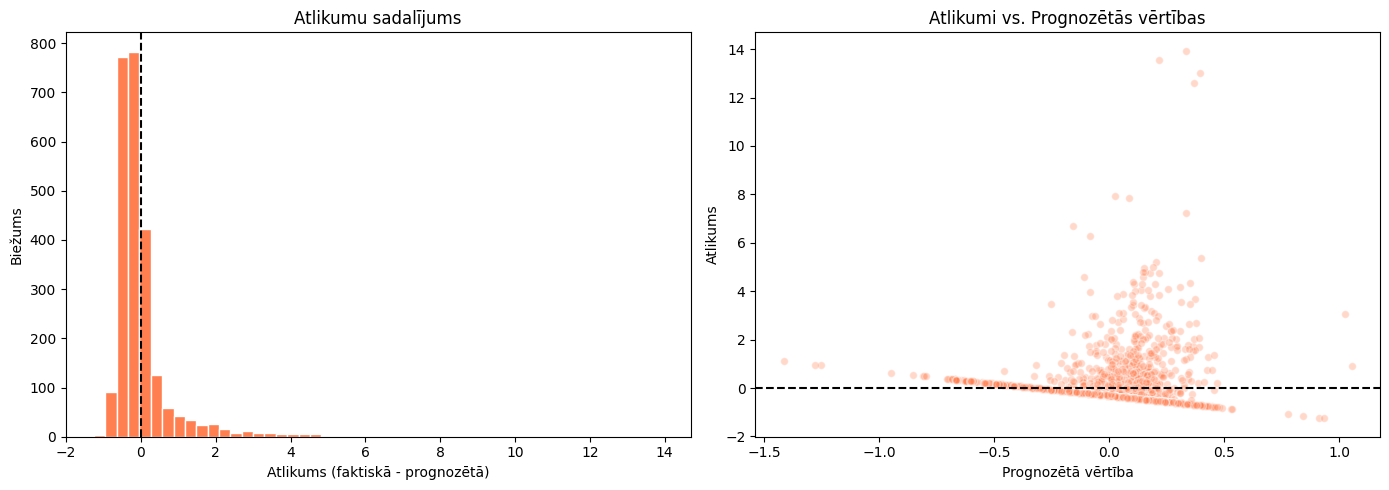

In [7]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Atlikumu sadalījums
axes[0].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[0].set_title('Atlikumu sadalījums')
axes[0].set_xlabel('Atlikums (faktiskā - prognozētā)')
axes[0].set_ylabel('Biežums')
axes[0].axvline(x=0, color='black', linestyle='--')

# Atlikumi vs. prognozētās vērtības
axes[1].scatter(y_pred, residuals, alpha=0.3, color='coral', edgecolors='white', s=30)
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_title('Atlikumi vs. Prognozētās vērtības')
axes[1].set_xlabel('Prognozētā vērtība')
axes[1].set_ylabel('Atlikums')

plt.tight_layout()
plt.show()


Scatter grafikā punkti ir izskaisīti haotiski un tālu no sarkanās līnijas, tas liecina par modeļa neprecizitāti.

Histogrammā atlikumi nav vienādi sadalīti ap 0 - pozitīvo atlikumu daļa stiepjas līdz 5. Tas norāda, ka modelis sistemātki prognozē par maz - īstās PageValues vērtības bieži ir daudz augstākas nekā modelis prognozē.

Abi grafiki apstiprina to, ka šis modelis ir slikts. Tas nespēj prognozēt augstās PageValues vērtības, kas ir tieši tie gadījumi, kas biznesam ir vissvarīgākie (klienti, kas pērk daudz).

Iemesls, visticamāk, ir datu sadalījums — vairāk nekā puse
apmeklētāju ir ar PageValues ≈ 0, un lineārā regresija
nespēj labi strādāt ar tik nelīdzsvarotiem datiem.

In [8]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Izveido pipeline: PolynomialFeatures → LinearRegression
poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

# Trenēšana
poly_pipeline.fit(X_train, y_train)

# Prognozes
y_pred_poly = poly_pipeline.predict(X_test)

# Metrikas
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print("=== Polinomiālā regresija (degree=2): rezultāti ===")
print(f"MAE:  {mae_poly:.4f}")
print(f"RMSE: {rmse_poly:.4f}")
print(f"R²:   {r2_poly:.4f}")


=== Polinomiālā regresija (degree=2): rezultāti ===
MAE:  0.4888
RMSE: 0.9993
R²:   0.0364


In [9]:
results = pd.DataFrame({
    'Modelis': ['Lineārā regresija', 'Polinomiālā regresija'],
    'MAE':  [mae, mae_poly],
    'RMSE': [rmse, rmse_poly],
    'R²':   [r2, r2_poly]
})

print(results.to_string(index=False))

              Modelis      MAE     RMSE       R²
    Lineārā regresija 0.500925 0.994572 0.045556
Polinomiālā regresija 0.488841 0.999347 0.036370


In [10]:
# R² uz treniņa datiem
r2_train_lr = r2_score(y_train, lr_model.predict(X_train))
r2_train_poly = r2_score(y_train, poly_pipeline.predict(X_train))

# R² uz testa datiem (jau aprēķināti iepriekš)
# r2 un r2_poly

print("=== R² salīdzinājums: treniņa vs. testa dati ===")
print(f"Lineārā regresija:     train={r2_train_lr:.4f}  test={r2:.4f}")
print(f"Polinomiālā regresija: train={r2_train_poly:.4f}  test={r2_poly:.4f}")

# Pārbaude uz overfitting
print("\n=== Overfitting pārbaude ===")
for nosaukums, r2_train, r2_test in [
    ("Lineārā regresija",     r2_train_lr,   r2),
    ("Polinomiālā regresija", r2_train_poly, r2_poly)
]:
    starpiba = r2_train - r2_test
    if starpiba > 0.10:
        print(f"⚠️  {nosaukums}: starpība = {starpiba:.4f} — iespējams overfitting!")
    else:
        print(f"✅  {nosaukums}: starpība = {starpiba:.4f} — overfitting nav konstatēts")

=== R² salīdzinājums: treniņa vs. testa dati ===
Lineārā regresija:     train=0.0568  test=0.0456
Polinomiālā regresija: train=0.1334  test=0.0364

=== Overfitting pārbaude ===
✅  Lineārā regresija: starpība = 0.0112 — overfitting nav konstatēts
✅  Polinomiālā regresija: starpība = 0.0971 — overfitting nav konstatēts


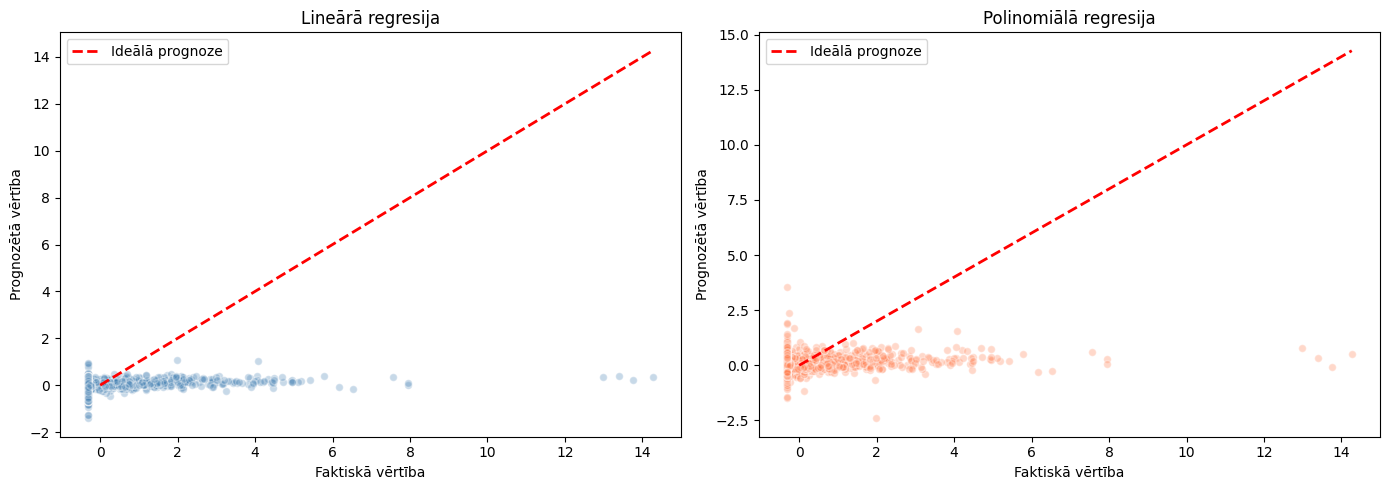

In [11]:
modeli = [
    (y_pred,      'Lineārā regresija',     'steelblue'),
    (y_pred_poly, 'Polinomiālā regresija', 'coral')
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (prognozes, nosaukums, krasa) in zip(axes, modeli):
    ax.scatter(y_test, prognozes, alpha=0.3, color=krasa, edgecolors='white', s=30)
    ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Ideālā prognoze')
    ax.set_title(nosaukums)
    ax.set_xlabel('Faktiskā vērtība')
    ax.set_ylabel('Prognozētā vērtība')
    ax.legend()

plt.tight_layout()
plt.show()

Polinomiālā regresija uzrāda nedaudz labāku MAE, taču lineārā regresija ir labāka pēc RMSE un R². Tā kā RMSE lielām kļūdām piešķir lielāku svaru un R² parāda vispārējo modeļa kvalitāti, lineārā regresija kopumā
ir nedaudz labāka. Tomēr neviens modelis neprognozē jūtami labāk par otru.

Polinomiālais modelis neuzlaboja R², pat pasliktināja — no 0.0456 līdz 0.0364. Abiem modeļiem R² ir tuvu nullei, kas liecina, ka ne lineārā, ne polinomiālā regresija nespēj pienācīgi izskaidrot PageValues variāciju.

Lineārajai regresijai overfitting pazīmes nav. Polinomiālajai
regresijai starpība (0.097) ir tuvu 0.10 slieksnim — train R²
ir gandrīz 4 reizes augstāks nekā test R². Tas liecina, ka
modelis iegaumē treniņa datus, nevis mācās vispārīgas
sakarības.

Biznesa vidē neieteiktu nevienu no šiem modeļiem, jo abi ir slikti un nebūtu izmantojami reālu lēmumu pieņemšanai. Ja tomēr kāda no šīm ir jāiesaka, es ieteiktu lineāro regresiju — ne tāpēc, ka tā ir
laba, bet tāpēc, ka tā ir vienkāršāka, saprotamāka un neuzrāda
overfitting pazīmes.